# Análise de Vendas com Python

## Análise exploratória de dados sobre vendas e faturamento

Projeto de portfólio — Pedro Vinícius

### Tecnologias utilizadas

- Python
- Pandas
- Matplotlib
- Google Colab

### Objetivo

Este projeto tem como objetivo analisar uma base de dados de vendas para identificar padrões de faturamento, volume de vendas, desempenho dos produtos e resultados por vendedor.

A análise busca transformar os dados em informações que possam auxiliar na compreensão dos resultados e na tomada de decisões.

Base de dados:


,Produto,Regiao,Vendedor,Quantidade,Preco_Unitario,Faturamento
0,Notebook,Nordeste,Ana,5,3500,17500
1,Mouse,Nordeste,Carlos,20,80,1600
2,Teclado,Sudeste,Maria,15,150,2250
3,Monitor,Sul,João,8,1200,9600
4,Notebook,Nordeste,Ana,7,3500,24500
5,Mouse,Sudeste,Carlos,25,80,2000
6,Teclado,Sul,Maria,18,150,2700
7,Monitor,Nordeste,João,10,1200,12000
8,Notebook,Sudeste,Ana,6,3500,21000
9,Mouse,Sul,Carlos,30,80,2400



Faturamento por produto:


,Faturamento
Produto,
Notebook,63000
Monitor,36000
Teclado,7950
Mouse,6000



Faturamento por região:


...

,Quantidade
Produto,
Mouse,75
Teclado,53
Monitor,30
Notebook,18



Valor médio por unidade:


,0
Produto,
Notebook,3500.0
Monitor,1200.0
Teclado,150.0
Mouse,80.0



Desempenho dos vendedores:


,Faturamento,Quantidade
Vendedor,,
Ana,63000,18
João,36000,30
Maria,7950,53
Carlos,6000,75


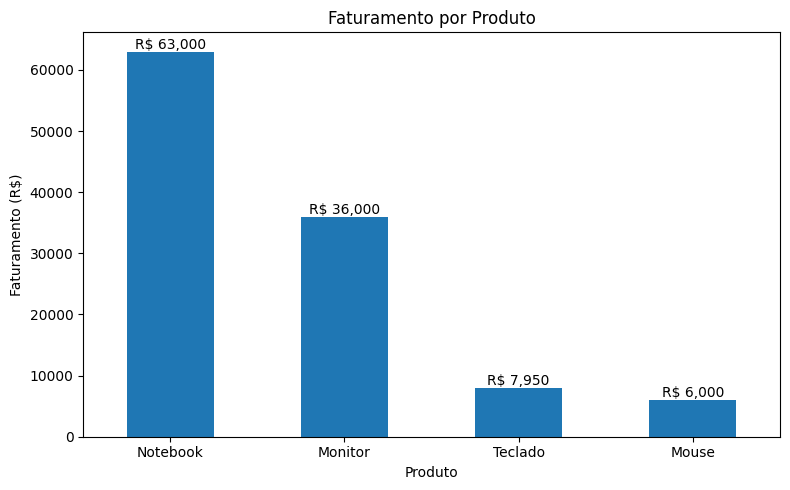

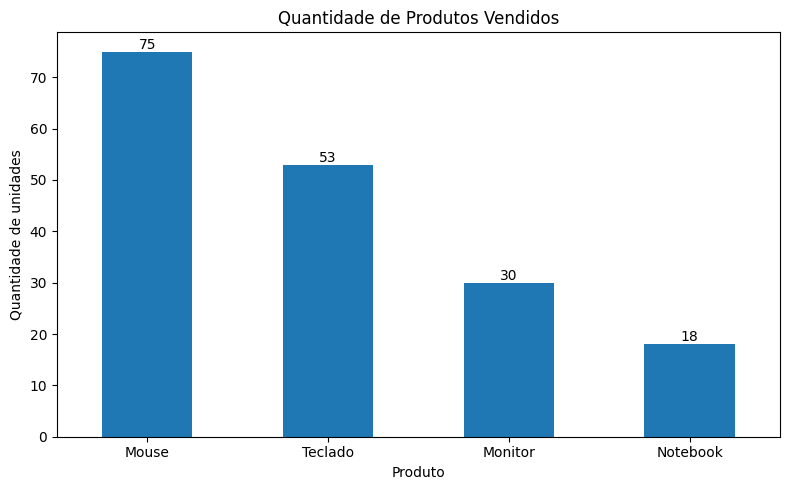

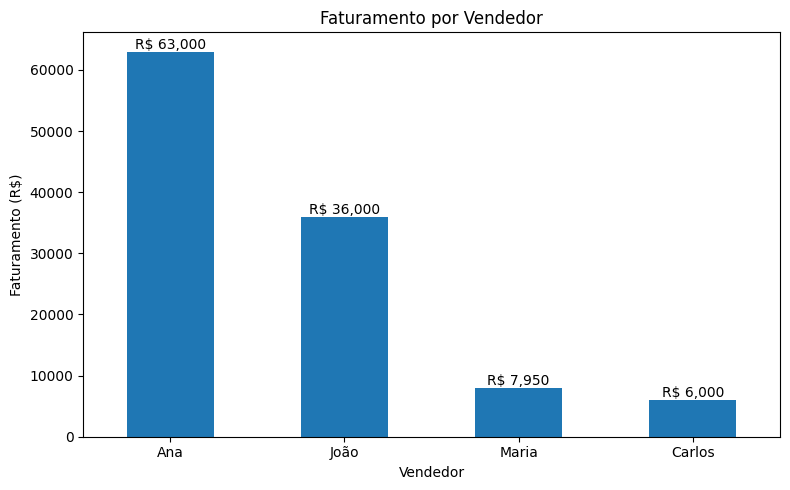

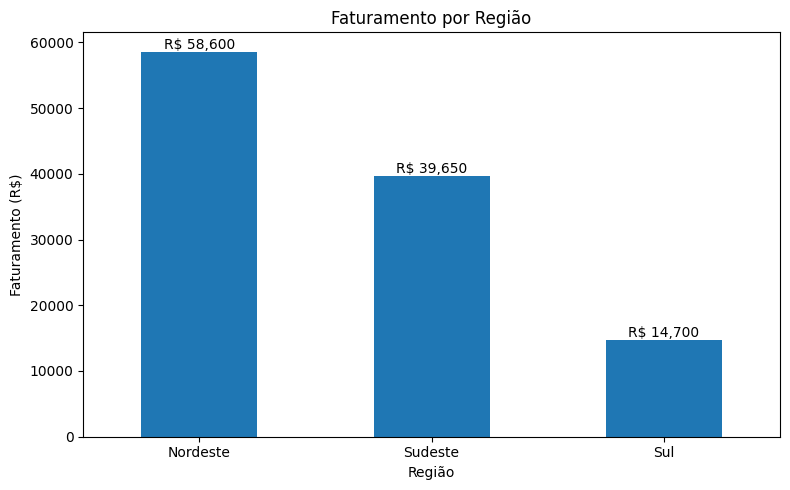

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


# 1. Preparação dos dados

dados = {
    "Produto": [
        "Notebook", "Mouse", "Teclado", "Monitor",
        "Notebook", "Mouse", "Teclado", "Monitor",
        "Notebook", "Mouse", "Teclado", "Monitor"
    ],
    "Regiao": [
        "Nordeste", "Nordeste", "Sudeste", "Sul",
        "Nordeste", "Sudeste", "Sul", "Nordeste",
        "Sudeste", "Sul", "Nordeste", "Sudeste"
    ],
    "Vendedor": [
        "Ana", "Carlos", "Maria", "João",
        "Ana", "Carlos", "Maria", "João",
        "Ana", "Carlos", "Maria", "João"
    ],
    "Quantidade": [
        5, 20, 15, 8,
        7, 25, 18, 10,
        6, 30, 20, 12
    ],
    "Preco_Unitario": [
        3500, 80, 150, 1200,
        3500, 80, 150, 1200,
        3500, 80, 150, 1200
    ]
}

df = pd.DataFrame(dados)


# 2. Cálculo do faturamento

df["Faturamento"] = df["Quantidade"] * df["Preco_Unitario"]

print("Base de dados:")
display(df)


# 3. Faturamento por produto

faturamento_produto = (
    df.groupby("Produto")["Faturamento"]
    .sum()
    .sort_values(ascending=False)
)

print("\nFaturamento por produto:")
display(faturamento_produto)


# 4. Faturamento por região

faturamento_regiao = (
    df.groupby("Regiao")["Faturamento"]
    .sum()
    .sort_values(ascending=False)
)

print("\nFaturamento por região:")
display(faturamento_regiao)


# 5. Faturamento por vendedor

faturamento_vendedor = (
    df.groupby("Vendedor")["Faturamento"]
    .sum()
    .sort_values(ascending=False)
)

print("\nFaturamento por vendedor:")
display(faturamento_vendedor)


# 6. Faturamento total

faturamento_total = df["Faturamento"].sum()

print(f"\nFaturamento total: R$ {faturamento_total:,.2f}")


# 7. Participação de cada produto no faturamento

participacao_produto = (
    faturamento_produto / faturamento_total * 100
).round(2)

print("\nParticipação no faturamento:")
display(participacao_produto)


# 8. Quantidade de produtos vendidos

quantidade_produto = (
    df.groupby("Produto")["Quantidade"]
    .sum()
    .sort_values(ascending=False)
)

print("\nQuantidade de produtos vendidos:")
display(quantidade_produto)


# 9. Ticket médio por produto

ticket_medio = (
    faturamento_produto / quantidade_produto
).sort_values(ascending=False)

print("\nValor médio por unidade:")
display(ticket_medio)


# 10. Desempenho dos vendedores

desempenho_vendedor = (
    df.groupby("Vendedor")
    .agg(
        Faturamento=("Faturamento", "sum"),
        Quantidade=("Quantidade", "sum")
    )
    .sort_values("Faturamento", ascending=False)
)

print("\nDesempenho dos vendedores:")
display(desempenho_vendedor)


# 11. Gráfico — Faturamento por produto

ax = faturamento_produto.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Faturamento por Produto")
plt.xlabel("Produto")
plt.ylabel("Faturamento (R$)")
plt.xticks(rotation=0)

for i, valor in enumerate(faturamento_produto):
    ax.text(
        i,
        valor,
        f"R$ {valor:,.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


# 12. Gráfico — Quantidade vendida por produto

ax = quantidade_produto.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Quantidade de Produtos Vendidos")
plt.xlabel("Produto")
plt.ylabel("Quantidade de unidades")
plt.xticks(rotation=0)

for i, valor in enumerate(quantidade_produto):
    ax.text(
        i,
        valor,
        f"{valor:.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


# 13. Gráfico — Faturamento por vendedor

ax = faturamento_vendedor.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Faturamento por Vendedor")
plt.xlabel("Vendedor")
plt.ylabel("Faturamento (R$)")
plt.xticks(rotation=0)

for i, valor in enumerate(faturamento_vendedor):
    ax.text(
        i,
        valor,
        f"R$ {valor:,.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


# 14. Gráfico — Faturamento por região

ax = faturamento_regiao.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Faturamento por Região")
plt.xlabel("Região")
plt.ylabel("Faturamento (R$)")
plt.xticks(rotation=0)

for i, valor in enumerate(faturamento_regiao):
    ax.text(
        i,
        valor,
        f"R$ {valor:,.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

# Principais Insights

O faturamento total da empresa analisada foi de R$ 112.950.

O Notebook apresentou o maior faturamento, representando 55,78% da receita total. O Monitor ficou em segundo lugar, com 31,87%.

Notebook e Monitor, juntos, representaram 87,65% do faturamento analisado, indicando uma forte concentração da receita nesses dois produtos.

Em relação ao volume de vendas, o Mouse apresentou a maior quantidade de unidades vendidas, com 75 unidades. Apesar disso, representou apenas 5,31% do faturamento.

O Notebook apresentou o maior valor médio por unidade, de R$ 3.500,00, o que explica a diferença entre seu volume de vendas e sua participação na receita.

Ana apresentou o maior faturamento entre os vendedores, com R$ 63.000,00. Entretanto, a comparação entre vendedores deve considerar o mix de produtos comercializado por cada um.

## Conclusão

A análise demonstra que volume de vendas e faturamento são métricas diferentes e devem ser avaliadas conjuntamente. Produtos com maior valor unitário podem gerar uma parcela significativa da receita mesmo apresentando menor volume de vendas.